# Imports 

In [1]:
import pandas as pd

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Bank Transaction Fraud Detection

## Dataset Description
This dataset contains 200,000 bank transaction records from Indian banks with features including customer demographics, transaction details, and fraud labels. The goal is to build machine learning models to detect fraudulent transactions.

In [3]:
df = pd.read_csv('other_data/Bank_Transaction_Fraud_Detection.csv')

## Data Extraction

In [4]:
df.head()

,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Customer_Contact,Transaction_Description,Customer_Email
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Osha Tella,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,4fa3208f-9e23-42dc-b330-844829d0c12c,23-01-2025,...,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0,INR,+9198579XXXXXX,Bitcoin transaction,oshaXXXXX@XXXXX.com
1,7c14ad51-781a-4db9-b7bd-67439c175262,Hredhaan Khosla,Female,51,Maharashtra,Nashik,Nashik Branch,Business,c9de0c06-2c4c-40a9-97ed-3c7b8f97c79c,11-01-2025,...,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0,INR,+9191074XXXXXX,Grocery delivery,hredhaanXXXX@XXXXXX.com
2,3a73a0e5-d4da-45aa-85f3-528413900a35,Ekani Nazareth,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,e41c55f9-c016-4ff3-872b-cae72467c75c,25-01-2025,...,Groceries,66817.99,ATM,"Bhagalpur, Bihar",Desktop,0,INR,+9197745XXXXXX,Mutual fund investment,ekaniXXX@XXXXXX.com
3,7902f4ef-9050-4a79-857d-9c2ea3181940,Yamini Ramachandran,Female,57,Tamil Nadu,Chennai,Chennai Branch,Business,7f7ee11b-ff2c-45a3-802a-49bc47c02ecb,19-01-2025,...,Entertainment,58177.08,POS Mobile App,"Chennai, Tamil Nadu",Mobile,0,INR,+9195889XXXXXX,Food delivery,yaminiXXXXX@XXXXXXX.com
4,3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9,Kritika Rege,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,f8e6ac6f-81a1-4985-bf12-f60967d852ef,30-01-2025,...,Entertainment,16108.56,Virtual Card,"Amritsar, Punjab",Mobile,0,INR,+9195316XXXXXX,Debt repayment,kritikaXXXX@XXXXXX.com


In [5]:
df.shape

(200000, 24)

In [6]:
df.columns

Index(['Customer_ID', 'Customer_Name', 'Gender', 'Age', 'State', 'City',
       'Bank_Branch', 'Account_Type', 'Transaction_ID', 'Transaction_Date',
       'Transaction_Time', 'Transaction_Amount', 'Merchant_ID',
       'Transaction_Type', 'Merchant_Category', 'Account_Balance',
       'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Is_Fraud',
       'Transaction_Currency', 'Customer_Contact', 'Transaction_Description',
       'Customer_Email'],
      dtype='object')

In [7]:
columns_to_drop = ["Customer_ID","Customer_Name", "Transaction_ID", "Merchant_ID","Customer_Contact","Transaction_Description", "Customer_Email", "Transaction_Currency"]
df.drop(columns=columns_to_drop, axis=1, inplace=True)

## Exploratory Data Analysis

In [8]:
df.head()

,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_Date,Transaction_Time,Transaction_Amount,Transaction_Type,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud
0,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,23-01-2025,16:04:07,32415.45,Transfer,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0
1,Female,51,Maharashtra,Nashik,Nashik Branch,Business,11-01-2025,17:14:53,43622.60,Bill Payment,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0
2,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,25-01-2025,03:09:52,63062.56,Bill Payment,Groceries,66817.99,ATM,"Bhagalpur, Bihar",Desktop,0
3,Female,57,Tamil Nadu,Chennai,Chennai Branch,Business,19-01-2025,12:27:02,14000.72,Debit,Entertainment,58177.08,POS Mobile App,"Chennai, Tamil Nadu",Mobile,0
4,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,30-01-2025,18:30:46,18335.16,Transfer,Entertainment,16108.56,Virtual Card,"Amritsar, Punjab",Mobile,0


In [9]:
df["Is_Fraud"].unique()

array([0, 1])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Gender                200000 non-null  object 
 1   Age                   200000 non-null  int64  
 2   State                 200000 non-null  object 
 3   City                  200000 non-null  object 
 4   Bank_Branch           200000 non-null  object 
 5   Account_Type          200000 non-null  object 
 6   Transaction_Date      200000 non-null  object 
 7   Transaction_Time      200000 non-null  object 
 8   Transaction_Amount    200000 non-null  float64
 9   Transaction_Type      200000 non-null  object 
 10  Merchant_Category     200000 non-null  object 
 11  Account_Balance       200000 non-null  float64
 12  Transaction_Device    200000 non-null  object 
 13  Transaction_Location  200000 non-null  object 
 14  Device_Type           200000 non-null  object 
 15  

In [11]:
df["year"] = pd.to_datetime(df["Transaction_Date"]).dt.year
df["month"] = pd.to_datetime(df["Transaction_Date"]).dt.month
df["day"] = pd.to_datetime(df["Transaction_Date"]).dt.day

df["hour"] = pd.to_datetime(df["Transaction_Time"], format="%H:%M:%S").dt.hour
df["minute"] = pd.to_datetime(df["Transaction_Time"], format="%H:%M:%S").dt.minute
df["second"] = pd.to_datetime(df["Transaction_Time"], format="%H:%M:%S").dt.second

df.drop(["Transaction_Time", "Transaction_Date"], axis=1, inplace=True)

/tmp/ipykernel_101799/489643442.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["year"] = pd.to_datetime(df["Transaction_Date"]).dt.year
/tmp/ipykernel_101799/489643442.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["month"] = pd.to_datetime(df["Transaction_Date"]).dt.month
/tmp/ipykernel_101799/489643442.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["day"] = pd.to_datetime(df["Transaction_Date"]).dt.day


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Gender                200000 non-null  object 
 1   Age                   200000 non-null  int64  
 2   State                 200000 non-null  object 
 3   City                  200000 non-null  object 
 4   Bank_Branch           200000 non-null  object 
 5   Account_Type          200000 non-null  object 
 6   Transaction_Amount    200000 non-null  float64
 7   Transaction_Type      200000 non-null  object 
 8   Merchant_Category     200000 non-null  object 
 9   Account_Balance       200000 non-null  float64
 10  Transaction_Device    200000 non-null  object 
 11  Transaction_Location  200000 non-null  object 
 12  Device_Type           200000 non-null  object 
 13  Is_Fraud              200000 non-null  int64  
 14  year                  200000 non-null  int32  
 15  

In [13]:
df.duplicated().sum()

0

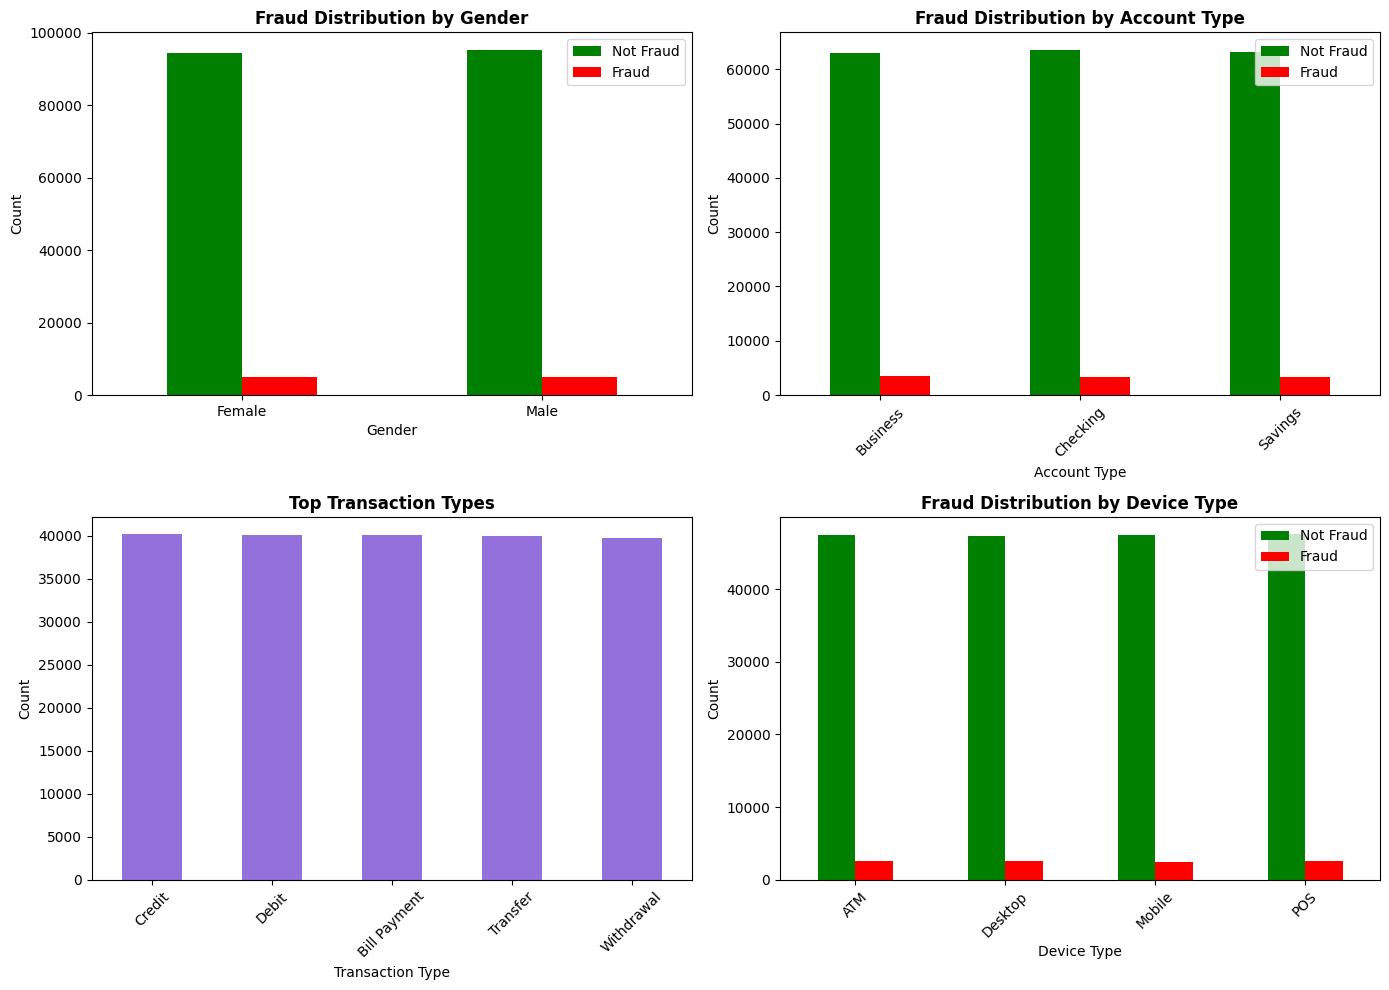

In [14]:
# Categorical features distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gender
gender_fraud = df.groupby(['Gender', 'Is_Fraud']).size().unstack(fill_value=0)
gender_fraud.plot(kind='bar', ax=axes[0, 0], color=['green', 'red'])
axes[0, 0].set_title('Fraud Distribution by Gender', fontweight='bold')
axes[0, 0].set_xlabel('Gender')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend(['Not Fraud', 'Fraud'])
axes[0, 0].tick_params(axis='x', rotation=0)

# Account Type
account_fraud = df.groupby(['Account_Type', 'Is_Fraud']).size().unstack(fill_value=0)
account_fraud.plot(kind='bar', ax=axes[0, 1], color=['green', 'red'])
axes[0, 1].set_title('Fraud Distribution by Account Type', fontweight='bold')
axes[0, 1].set_xlabel('Account Type')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend(['Not Fraud', 'Fraud'])
axes[0, 1].tick_params(axis='x', rotation=45)

# Transaction Type
trans_type = df['Transaction_Type'].value_counts().head(10)
trans_type.plot(kind='bar', ax=axes[1, 0], color='mediumpurple')
axes[1, 0].set_title('Top Transaction Types', fontweight='bold')
axes[1, 0].set_xlabel('Transaction Type')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# Device Type
device_fraud = df.groupby(['Device_Type', 'Is_Fraud']).size().unstack(fill_value=0)
device_fraud.plot(kind='bar', ax=axes[1, 1], color=['green', 'red'])
axes[1, 1].set_title('Fraud Distribution by Device Type', fontweight='bold')
axes[1, 1].set_xlabel('Device Type')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend(['Not Fraud', 'Fraud'])
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

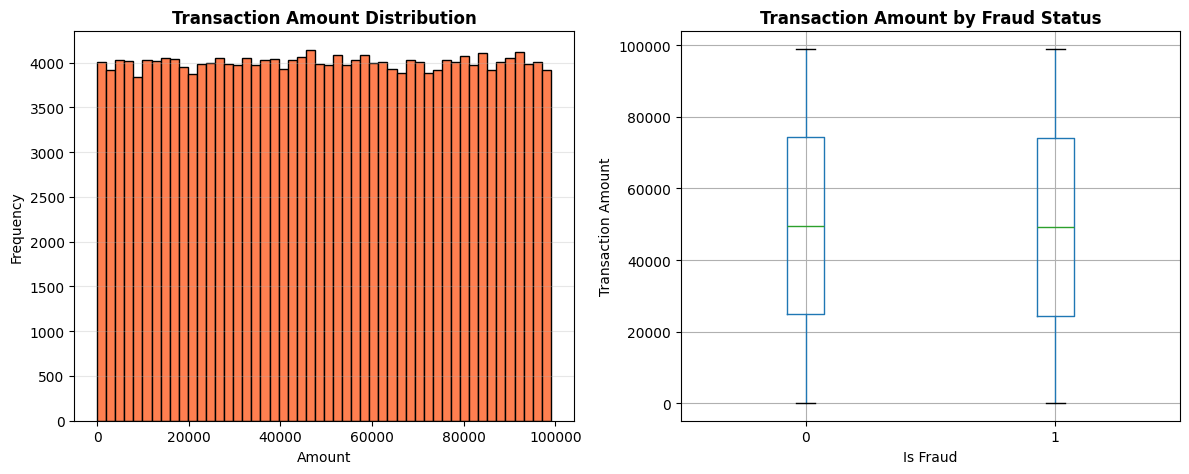

In [15]:
# Transaction amount distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['Transaction_Amount'], bins=50, color='coral', edgecolor='black')
plt.title('Transaction Amount Distribution', fontweight='bold')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
df.boxplot(column='Transaction_Amount', by='Is_Fraud', ax=plt.gca())
plt.title('Transaction Amount by Fraud Status', fontweight='bold')
plt.suptitle('')
plt.xlabel('Is Fraud')
plt.ylabel('Transaction Amount')

plt.tight_layout()
plt.show()

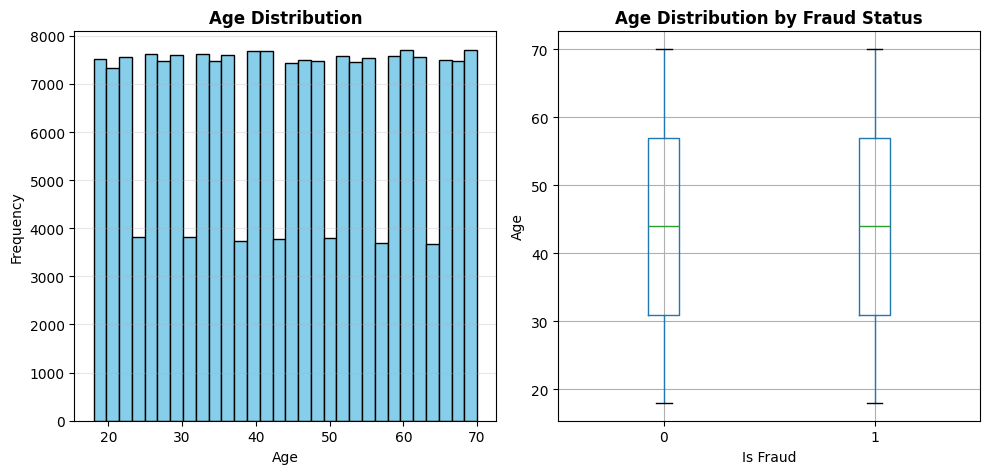

In [16]:
# Age distribution
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(df['Age'], bins=30, color='skyblue', edgecolor='black')
plt.title('Age Distribution', fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
df.boxplot(column='Age', by='Is_Fraud', figsize=(5, 5), ax=plt.gca())
plt.title('Age Distribution by Fraud Status', fontweight='bold')
plt.suptitle('')
plt.xlabel('Is Fraud')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

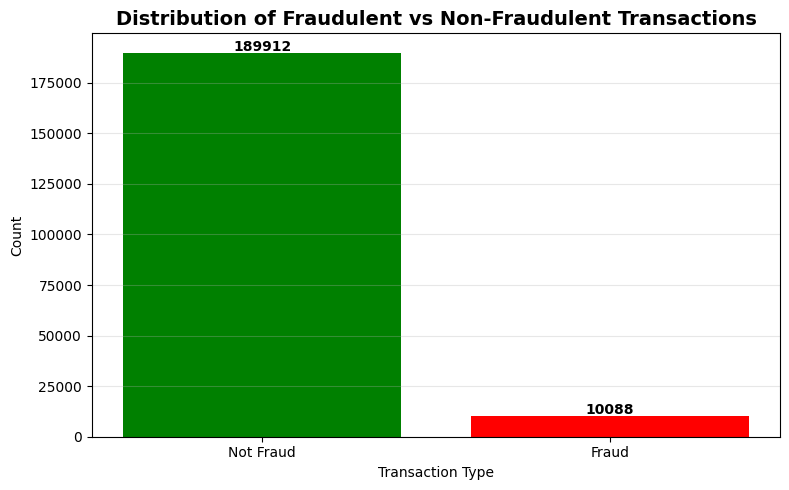

In [17]:
# Fraud distribution
plt.figure(figsize=(8, 5))
fraud_counts = df['Is_Fraud'].value_counts()
plt.bar(['Not Fraud', 'Fraud'], fraud_counts.values, color=['green', 'red'])
plt.title('Distribution of Fraudulent vs Non-Fraudulent Transactions', fontsize=14, fontweight='bold')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(fraud_counts.values):
    plt.text(i, v + 1000, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
df.isnull().sum()

Gender                  0
Age                     0
State                   0
City                    0
Bank_Branch             0
Account_Type            0
Transaction_Amount      0
Transaction_Type        0
Merchant_Category       0
Account_Balance         0
Transaction_Device      0
Transaction_Location    0
Device_Type             0
Is_Fraud                0
year                    0
month                   0
day                     0
hour                    0
minute                  0
second                  0
dtype: int64

In [19]:
Categorical = [i for i in df.columns if df[i].dtype == 'O']
Numerical = [i for i in df.columns if df[i].dtype != 'O']

In [20]:
print(f"Categorical: \n{Categorical}\n\nNumerical: \n{Numerical}")

Categorical: 
['Gender', 'State', 'City', 'Bank_Branch', 'Account_Type', 'Transaction_Type', 'Merchant_Category', 'Transaction_Device', 'Transaction_Location', 'Device_Type']

Numerical: 
['Age', 'Transaction_Amount', 'Account_Balance', 'Is_Fraud', 'year', 'month', 'day', 'hour', 'minute', 'second']


In [21]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedGroupKFold 
from imblearn.over_sampling import SMOTE

## Data Transformation

In [22]:
label_encoder = LabelEncoder()
for i in Categorical:
    df[i] = label_encoder.fit_transform(df[i])

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Gender                200000 non-null  int64  
 1   Age                   200000 non-null  int64  
 2   State                 200000 non-null  int64  
 3   City                  200000 non-null  int64  
 4   Bank_Branch           200000 non-null  int64  
 5   Account_Type          200000 non-null  int64  
 6   Transaction_Amount    200000 non-null  float64
 7   Transaction_Type      200000 non-null  int64  
 8   Merchant_Category     200000 non-null  int64  
 9   Account_Balance       200000 non-null  float64
 10  Transaction_Device    200000 non-null  int64  
 11  Transaction_Location  200000 non-null  int64  
 12  Device_Type           200000 non-null  int64  
 13  Is_Fraud              200000 non-null  int64  
 14  year                  200000 non-null  int32  
 15  

In [24]:
X = df.drop(columns=['Is_Fraud'])
Y = df["Is_Fraud"]

x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, stratify=Y)

## Train-Test Split with Undersampling

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## Model Loading

In [26]:
log_model = LogisticRegression(class_weight='balanced', max_iter=100)
log_model.fit(x_train, y_train)

/home/theslender/anaconda3/envs/all_purpose/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Model Training and Testing

### Logistic Regression

              precision    recall  f1-score   support

           0       0.95      0.50      0.66     37982
           1       0.05      0.50      0.09      2018

    accuracy                           0.50     40000
   macro avg       0.50      0.50      0.37     40000
weighted avg       0.90      0.50      0.63     40000



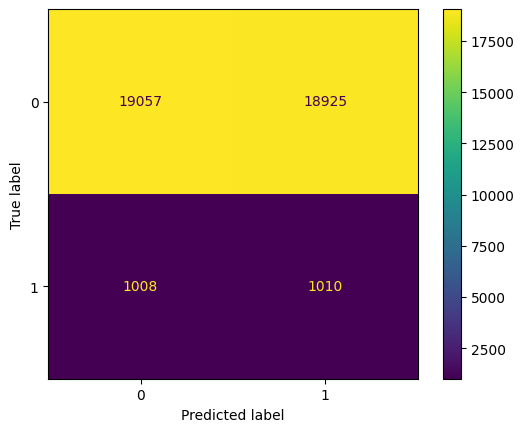

In [27]:
y_pred = log_model.predict(x_test)
print(classification_report(y_true=y_test, y_pred=y_pred))
cm = confusion_matrix(y_test, y_pred, labels=log_model.classes_)
ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=log_model.classes_).plot()
plt.show()

In [33]:
rf_model = RandomForestClassifier(n_estimators=50, class_weight='balanced')

rf_model.fit(x_train, y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Random Forest Classifier

              precision    recall  f1-score   support

           0       0.95      1.00      0.97     37982
           1       0.00      0.00      0.00      2018

    accuracy                           0.95     40000
   macro avg       0.47      0.50      0.49     40000
weighted avg       0.90      0.95      0.92     40000



/home/theslender/anaconda3/envs/all_purpose/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/theslender/anaconda3/envs/all_purpose/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/theslender/anaconda3/envs/all_purpose/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

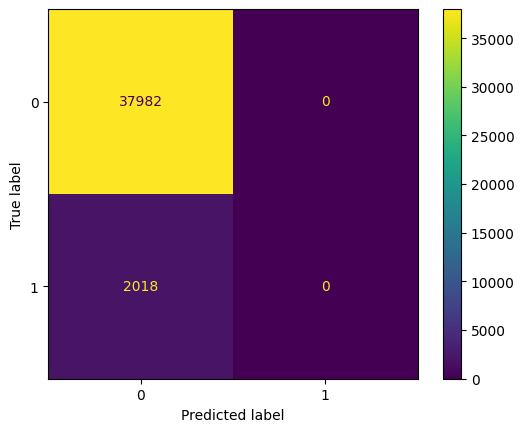

In [34]:
rf_y_pred = rf_model.predict(x_test)
print(classification_report(y_true=y_test, y_pred=rf_y_pred))
cm = confusion_matrix(y_test, rf_y_pred, labels=rf_model.classes_)
ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=rf_model.classes_).plot()
plt.show()

In [30]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    )
xgb_model.fit(x_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### XGBoost Classifier

In [31]:
xgb_y_pred = xgb_model.predict(x_test)
print(classification_report(y_true=y_test, y_pred=xgb_y_pred))

              precision    recall  f1-score   support

           0       0.95      0.71      0.81     37982
           1       0.05      0.30      0.09      2018

    accuracy                           0.69     40000
   macro avg       0.50      0.50      0.45     40000
weighted avg       0.90      0.69      0.77     40000



              precision    recall  f1-score   support

           0       0.95      0.71      0.81     37982
           1       0.05      0.30      0.09      2018

    accuracy                           0.69     40000
   macro avg       0.50      0.50      0.45     40000
weighted avg       0.90      0.69      0.77     40000



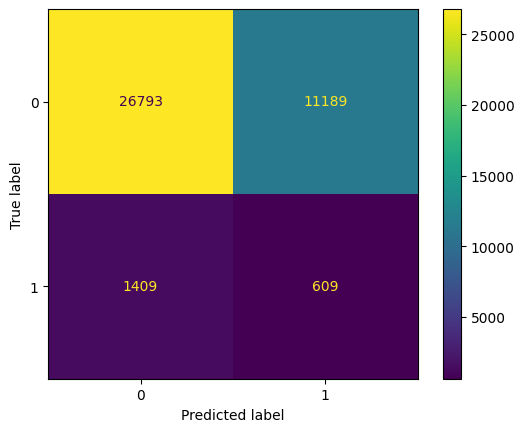

In [32]:
print(classification_report(y_true=y_test, y_pred=xgb_y_pred))
cm = confusion_matrix(y_test, xgb_y_pred, labels=xgb_model.classes_)
ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=xgb_model.classes_).plot()
plt.show()

## Improved Techniques for Imbalanced Data

The current models are failing to detect fraud because they're overwhelmed by the majority class (95% non-fraud). Let's implement several strategies:

### Strategy 1: SMOTE (Synthetic Minority Over-sampling Technique)
- Creates synthetic samples of the minority class
- Balances the training data without simply duplicating examples

### Strategy 2: Better Evaluation Metrics
- **Confusion Matrix**: Shows true/false positives/negatives
- **ROC-AUC**: Measures model's ability to distinguish classes
- **Precision-Recall Curve**: Better for imbalanced data than ROC
- **Focus on Recall**: In fraud detection, catching frauds is more important than avoiding false alarms

### Strategy 3: Threshold Tuning
- Adjust decision threshold to prioritize fraud detection
- Balance between catching frauds (recall) and precision

In [ ]:
# Import additional metrics
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, auc
from sklearn.metrics import ConfusionMatrixDisplay

# Check class distribution before SMOTE
print("Before SMOTE:")
print(f"Non-Fraud: {len(y_train[y_train == 0])} ({len(y_train[y_train == 0])/len(y_train)*100:.2f}%)")
print(f"Fraud: {len(y_train[y_train == 1])} ({len(y_train[y_train == 1])/len(y_train)*100:.2f}%)")

In [ ]:
# Apply SMOTE to balance the training data
smote = SMOTE(random_state=42, k_neighbors=5)
x_train_smote, y_train_smote = smote.fit_resample(x_train_scaled, y_train)

print("\nAfter SMOTE:")
print(f"Non-Fraud: {len(y_train_smote[y_train_smote == 0])} ({len(y_train_smote[y_train_smote == 0])/len(y_train_smote)*100:.2f}%)")
print(f"Fraud: {len(y_train_smote[y_train_smote == 1])} ({len(y_train_smote[y_train_smote == 1])/len(y_train_smote)*100:.2f}%)")
print(f"\nTotal training samples increased from {len(y_train)} to {len(y_train_smote)}")

In [ ]:
# Scale test data (important!)
x_test_scaled = scaler.transform(x_test)

# Helper function to evaluate models comprehensively
def evaluate_model(model, X_test, y_test, model_name="Model"):
    """
    Comprehensive evaluation for fraud detection models
    """
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # 1. Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Fraud', 'Fraud'])
    disp.plot(ax=axes[0, 0], cmap='Blues', values_format='d')
    axes[0, 0].set_title(f'{model_name} - Confusion Matrix', fontweight='bold', fontsize=12)
    
    # 2. ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    axes[0, 1].set_xlabel('False Positive Rate')
    axes[0, 1].set_ylabel('True Positive Rate (Recall)')
    axes[0, 1].set_title(f'{model_name} - ROC Curve', fontweight='bold', fontsize=12)
    axes[0, 1].legend(loc="lower right")
    axes[0, 1].grid(alpha=0.3)
    
    # 3. Precision-Recall Curve (better for imbalanced data)
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall, precision)
    axes[1, 0].plot(recall, precision, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
    axes[1, 0].set_xlabel('Recall')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].set_title(f'{model_name} - Precision-Recall Curve', fontweight='bold', fontsize=12)
    axes[1, 0].legend(loc="upper right")
    axes[1, 0].grid(alpha=0.3)
    
    # 4. Classification Report as text
    from sklearn.metrics import classification_report
    report = classification_report(y_test, y_pred, target_names=['Non-Fraud', 'Fraud'])
    axes[1, 1].text(0.1, 0.5, report, fontsize=10, family='monospace', verticalalignment='center')
    axes[1, 1].axis('off')
    axes[1, 1].set_title(f'{model_name} - Classification Report', fontweight='bold', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Print key metrics
    print(f"\n{'='*60}")
    print(f"{model_name} - KEY METRICS FOR FRAUD DETECTION")
    print(f"{'='*60}")
    print(f"ROC-AUC Score: {roc_auc:.4f}")
    print(f"PR-AUC Score: {pr_auc:.4f}")
    
    # Calculate fraud-specific metrics
    tn, fp, fn, tp = cm.ravel()
    fraud_recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fraud_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    fraud_f1 = 2 * (fraud_precision * fraud_recall) / (fraud_precision + fraud_recall) if (fraud_precision + fraud_recall) > 0 else 0
    
    print(f"\nFRAUD DETECTION METRICS (Class 1):")
    print(f"  Recall (Fraud Caught): {fraud_recall:.4f} ({tp}/{tp+fn} frauds detected)")
    print(f"  Precision: {fraud_precision:.4f} ({tp}/{tp+fp} fraud predictions correct)")
    print(f"  F1-Score: {fraud_f1:.4f}")
    print(f"\nConfusion Matrix Breakdown:")
    print(f"  True Negatives (Correct Non-Fraud): {tn}")
    print(f"  False Positives (False Alarms): {fp}")
    print(f"  False Negatives (Missed Frauds): {fn}")
    print(f"  True Positives (Caught Frauds): {tp}")
    print(f"{'='*60}\n")
    
    return {
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'fraud_recall': fraud_recall,
        'fraud_precision': fraud_precision
    }

### Models Trained with SMOTE Data

In [ ]:
# Logistic Regression with SMOTE
print("Training Logistic Regression with SMOTE data...")
log_model_smote = LogisticRegression(max_iter=1000, random_state=42)
log_model_smote.fit(x_train_smote, y_train_smote)

results_log_smote = evaluate_model(log_model_smote, x_test_scaled, y_test, "Logistic Regression (SMOTE)")

In [ ]:
# Random Forest with SMOTE and class weights
print("Training Random Forest with SMOTE data and class weights...")
rf_model_smote = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',  # Adding class weights
    random_state=42,
    n_jobs=-1
)
rf_model_smote.fit(x_train_smote, y_train_smote)

results_rf_smote = evaluate_model(rf_model_smote, x_test_scaled, y_test, "Random Forest (SMOTE + Class Weights)")

In [ ]:
# XGBoost with SMOTE
print("Training XGBoost with SMOTE data...")
xgb_model_smote = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_model_smote.fit(x_train_smote, y_train_smote)

results_xgb_smote = evaluate_model(xgb_model_smote, x_test_scaled, y_test, "XGBoost (SMOTE)")

### Threshold Tuning for Optimal Fraud Detection

By default, models use 0.5 as the classification threshold. For fraud detection, we can lower this threshold to catch more frauds (increase recall) at the cost of more false alarms (lower precision).

In [ ]:
def find_optimal_threshold(model, X_test, y_test, target_recall=0.90):
    """
    Find optimal classification threshold to achieve target recall for fraud detection
    
    Parameters:
    - model: trained model with predict_proba method
    - X_test: test features
    - y_test: test labels
    - target_recall: minimum desired recall for fraud class (default 0.90 = 90%)
    
    Returns:
    - optimal_threshold: threshold that achieves target recall with best precision
    """
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Test different thresholds
    thresholds = np.arange(0.05, 0.95, 0.05)
    results = []
    
    for threshold in thresholds:
        y_pred_thresh = (y_pred_proba >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()
        
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        results.append({
            'threshold': threshold,
            'recall': recall,
            'precision': precision,
            'f1': f1,
            'tp': tp,
            'fp': fp,
            'fn': fn,
            'tn': tn
        })
    
    df_results = pd.DataFrame(results)
    
    # Find thresholds that meet minimum recall requirement
    valid_thresholds = df_results[df_results['recall'] >= target_recall]
    
    if len(valid_thresholds) == 0:
        print(f"Warning: No threshold achieves {target_recall*100}% recall")
        print(f"Best recall achieved: {df_results['recall'].max()*100:.2f}%")
        # Return threshold with best F1 score
        optimal_idx = df_results['f1'].idxmax()
    else:
        # Among valid thresholds, choose one with best precision (or F1)
        optimal_idx = valid_thresholds['precision'].idxmax()
    
    optimal_threshold = df_results.loc[optimal_idx, 'threshold']
    
    # Visualize threshold tuning
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Precision-Recall vs Threshold
    axes[0].plot(df_results['threshold'], df_results['precision'], 'b-', label='Precision', linewidth=2)
    axes[0].plot(df_results['threshold'], df_results['recall'], 'r-', label='Recall', linewidth=2)
    axes[0].plot(df_results['threshold'], df_results['f1'], 'g-', label='F1-Score', linewidth=2)
    axes[0].axvline(optimal_threshold, color='black', linestyle='--', label=f'Optimal = {optimal_threshold:.2f}')
    axes[0].axhline(target_recall, color='orange', linestyle=':', alpha=0.5, label=f'Target Recall = {target_recall:.2f}')
    axes[0].set_xlabel('Classification Threshold')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Metrics vs Classification Threshold', fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Plot 2: TP, FP, FN vs Threshold
    axes[1].plot(df_results['threshold'], df_results['tp'], 'g-', label='True Positives', linewidth=2)
    axes[1].plot(df_results['threshold'], df_results['fp'], 'r-', label='False Positives', linewidth=2)
    axes[1].plot(df_results['threshold'], df_results['fn'], 'orange', label='False Negatives', linewidth=2)
    axes[1].axvline(optimal_threshold, color='black', linestyle='--', label=f'Optimal = {optimal_threshold:.2f}')
    axes[1].set_xlabel('Classification Threshold')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Confusion Matrix Components vs Threshold', fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print results
    optimal_result = df_results.loc[optimal_idx]
    print(f"\n{'='*60}")
    print(f"OPTIMAL THRESHOLD ANALYSIS (Target Recall: {target_recall*100}%)")
    print(f"{'='*60}")
    print(f"Optimal Threshold: {optimal_threshold:.3f}")
    print(f"\nPerformance at Optimal Threshold:")
    print(f"  Fraud Recall: {optimal_result['recall']*100:.2f}% ({optimal_result['tp']:.0f}/{optimal_result['tp']+optimal_result['fn']:.0f} frauds caught)")
    print(f"  Precision: {optimal_result['precision']*100:.2f}% ({optimal_result['tp']:.0f}/{optimal_result['tp']+optimal_result['fp']:.0f} fraud predictions correct)")
    print(f"  F1-Score: {optimal_result['f1']:.4f}")
    print(f"  False Positives (False Alarms): {optimal_result['fp']:.0f}")
    print(f"  False Negatives (Missed Frauds): {optimal_result['fn']:.0f}")
    print(f"{'='*60}\n")
    
    return optimal_threshold, df_results

In [ ]:
# Apply threshold tuning to Random Forest (usually performs well with SMOTE)
# Try to achieve 90% fraud recall
print("Finding optimal threshold for Random Forest model...")
optimal_thresh_rf, threshold_results_rf = find_optimal_threshold(
    rf_model_smote, 
    x_test_scaled, 
    y_test, 
    target_recall=0.90
)

In [ ]:
# Apply threshold tuning to XGBoost
print("Finding optimal threshold for XGBoost model...")
optimal_thresh_xgb, threshold_results_xgb = find_optimal_threshold(
    xgb_model_smote, 
    x_test_scaled, 
    y_test, 
    target_recall=0.90
)

### Model Comparison Summary

In [ ]:
# Compare all models
comparison_data = {
    'Model': [
        'Logistic Regression (SMOTE)',
        'Random Forest (SMOTE + Class Weights)',
        'XGBoost (SMOTE)'
    ],
    'ROC-AUC': [
        results_log_smote['roc_auc'],
        results_rf_smote['roc_auc'],
        results_xgb_smote['roc_auc']
    ],
    'PR-AUC': [
        results_log_smote['pr_auc'],
        results_rf_smote['pr_auc'],
        results_xgb_smote['pr_auc']
    ],
    'Fraud Recall': [
        results_log_smote['fraud_recall'],
        results_rf_smote['fraud_recall'],
        results_xgb_smote['fraud_recall']
    ],
    'Fraud Precision': [
        results_log_smote['fraud_precision'],
        results_rf_smote['fraud_precision'],
        results_xgb_smote['fraud_precision']
    ]
}

df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.round(4)

print("\n" + "="*80)
print("MODEL COMPARISON - FRAUD DETECTION PERFORMANCE")
print("="*80)
print(df_comparison.to_string(index=False))
print("="*80)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_pos = np.arange(len(df_comparison))
width = 0.35

# Plot 1: ROC-AUC and PR-AUC
axes[0].bar(x_pos - width/2, df_comparison['ROC-AUC'], width, label='ROC-AUC', color='steelblue')
axes[0].bar(x_pos + width/2, df_comparison['PR-AUC'], width, label='PR-AUC', color='coral')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('AUC Score')
axes[0].set_title('Model Comparison: AUC Scores', fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(df_comparison['Model'], rotation=15, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1])

# Plot 2: Fraud Recall and Precision
axes[1].bar(x_pos - width/2, df_comparison['Fraud Recall'], width, label='Fraud Recall', color='green')
axes[1].bar(x_pos + width/2, df_comparison['Fraud Precision'], width, label='Fraud Precision', color='purple')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Score')
axes[1].set_title('Model Comparison: Fraud Detection Metrics', fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(df_comparison['Model'], rotation=15, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

# Find best model
best_recall_idx = df_comparison['Fraud Recall'].idxmax()
best_auc_idx = df_comparison['ROC-AUC'].idxmax()

print(f"\nBest Model for Fraud Recall: {df_comparison.loc[best_recall_idx, 'Model']} ({df_comparison.loc[best_recall_idx, 'Fraud Recall']*100:.2f}%)")
print(f"Best Model for ROC-AUC: {df_comparison.loc[best_auc_idx, 'Model']} ({df_comparison.loc[best_auc_idx, 'ROC-AUC']:.4f})")

## Additional Strategies for Further Improvement

### Other Techniques to Try:

1. **Alternative Sampling Methods**:
   - **ADASYN**: Adaptive Synthetic Sampling (focuses on harder-to-learn minority samples)
   - **Random Under-sampling**: Reduce majority class samples
   - **Tomek Links**: Remove borderline samples
   - **Combination**: Use both over-sampling and under-sampling

2. **Cost-Sensitive Learning**:
   - Assign higher misclassification costs to fraud cases
   - Use `sample_weight` parameter in sklearn models
   - Example: Treat missing 1 fraud as costly as 10 false alarms

3. **Ensemble Methods**:
   - **Stacking**: Combine predictions from multiple models
   - **Balanced Bagging**: Train multiple models on balanced subsets
   - **EasyEnsemble**: Combine undersampled models

4. **Anomaly Detection Approaches**:
   - **Isolation Forest**: Treats fraud as anomalies
   - **One-Class SVM**: Learn only from non-fraud samples
   - **Autoencoders**: Neural networks that learn normal patterns

5. **Feature Engineering**:
   - Transaction velocity features (transactions per hour/day)
   - Deviation from user's typical behavior
   - Location-based features (distance from usual location)
   - Time-based features (unusual hours)

6. **Advanced Models**:
   - **LightGBM**: Often faster than XGBoost with similar performance
   - **CatBoost**: Handles categorical features well
   - **Neural Networks**: Deep learning with custom architectures

### Example: Alternative Sampling with ADASYN

In [ ]:
# Example: Using ADASYN instead of SMOTE
from imblearn.over_sampling import ADASYN

# Apply ADASYN
adasyn = ADASYN(random_state=42, n_neighbors=5)
x_train_adasyn, y_train_adasyn = adasyn.fit_resample(x_train_scaled, y_train)

print(f"ADASYN Results:")
print(f"Non-Fraud: {len(y_train_adasyn[y_train_adasyn == 0])}")
print(f"Fraud: {len(y_train_adasyn[y_train_adasyn == 1])}")

# Train Random Forest with ADASYN
rf_adasyn = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_adasyn.fit(x_train_adasyn, y_train_adasyn)

# Evaluate
results_rf_adasyn = evaluate_model(rf_adasyn, x_test_scaled, y_test, "Random Forest (ADASYN)")